# FX Volatility Forecasting Notebook

This notebook demonstrates a workflow for predicting future FX volatility using candle data. It covers feature engineering, model training, and evaluation.

## Contents

1. [Modules](#Modules) – Import necessary Python packages and custom modules.  
2. [Data](#Data) – Load and inspect FX candle data, including timestamps, open, high, low, and close prices.  
3. [Features](#Features) - Compute features such as log returns and high-low ranges.
- [High-low range](#high-low-range)
- [Open-close difference](#open-close-difference)
- [Log returns](#log-returns)
- [Logged lag returns](#logged-lag-returns)
- [Rolling statistics of log returns](#rolling-statistics-of-log-returnsfeature)
- [Past rolling volatility](#past-rolling-volatility)
- [Lagged rolling volatility](#lagged-rolling-volatility)
- [Multi-window rolling volatility](#multi-window-rolling-volatility)
- [Volatility slope](#volatility-slope)
- [Volatility z-score](#volatility-z-score)
4. [Target](#Target) - Target of the candle data that we are aiming to predict.
- [Future rolling volatility](#future-volatility-target)
5. [Machine Learning](#Machine-Learning) – Train a Gradient Boosting Machine to predict future volatility, validate performance, and visualize results.
6. [Model Performance Evaluation](#model-performance-evaluation) - Evaluates the LightGBM volatility forecasting model against multiple baselines and visualizes feature importance.

## Modules

In [304]:
import sys
sys.path.append('../src')
import numpy as np
from IPython.display import Markdown
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from volare import data, features, model, predict, visualisation

from importlib import reload
# reload(features)
reload(model)
# reload(visualisation)

mpl.style.use('../styles/science.mplstyle')

## Data
- Read in candle (OHLC) data
- Choose candle data for one symbol
- Test setup on first N rows using (`nrows`) 

In [2]:
file = 'questdb-eurgbp.csv'
nrows = 300000

currencies = file.split('-')[1].split('.')[0]  # 'eurgbp'
base_currency = currencies[:3].upper()   # 'EUR'
quote_currency = currencies[3:].upper()
display(Markdown(f"## Using candle data for {base_currency}-{quote_currency}"))

df = data.load_candles('../data/'+file,nrows=300000)
df.head()

## Using candle data for EUR-GBP

,timestamp,symbol,open,high,low,close
0,2024-02-18 22:08:40+00:00,EUR/GBP,0.855025,0.855025,0.855025,0.855025
1,2024-02-18 22:08:50+00:00,EUR/GBP,0.855025,0.855025,0.855025,0.855025
2,2024-02-18 22:09:00+00:00,EUR/GBP,0.855025,0.855030,0.855025,0.855030
3,2024-02-18 22:09:10+00:00,EUR/GBP,0.855030,0.855030,0.855025,0.855025
4,2024-02-18 22:09:20+00:00,EUR/GBP,0.855025,0.855025,0.855015,0.855015


## Forecast Horizon
- Define the time period over which we want to predict future volatility.
- This horizon is used to compute the rolling future volatility target (`rolling_future_vol`) for training the model.
- The horizon should be shorter than or comparable to the feature rolling window to ensure meaningful predictions.
- Can be adjusted dynamically to see how different forecast lengths affect model performance.
- Any time gaps in the data do not affect the model, as it sees candles not time.

In [81]:
hmins = 30
forecast_horizon = hmins*60

## Features

### High-Low Range (`high_low_range`)
- Measures the price fluctuation within each candle (high minus low, as a fraction of the open price), capturing intra-candle volatility.  
- Provides complementary information to rolling volatility and log returns, highlighting periods of rapid price swings that may not be evident from open-close changes alone.  
- Helps the model detect short-term spikes in volatility, improving sensitivity to sudden market movements.

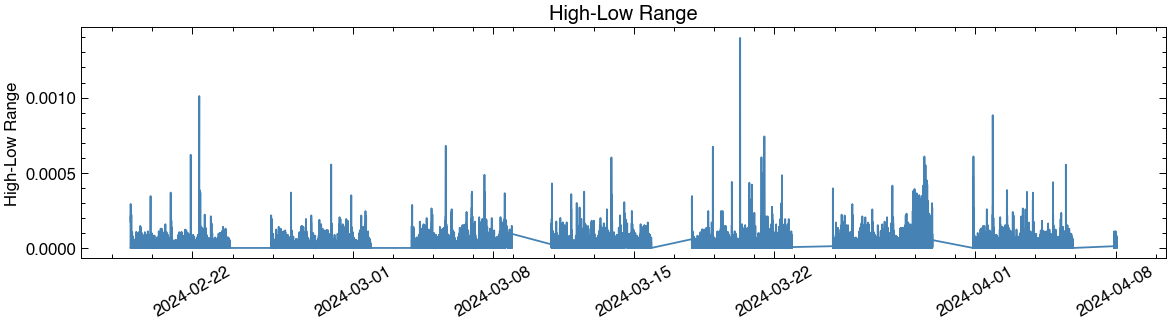

In [ ]:
df = features.compute_high_low_range(df)

x = df['timestamp'].values
y = df['high_low_range']
plt.figure(figsize=(14,3))
plt.plot(x, y, color='steelblue')
plt.ylabel('High-Low Range')
plt.title('High-Low Range')
plt.xticks(rotation=30)
plt.savefig('../results/plots/high_low_range.png')
plt.show()

### Open-Close Difference (`open_close`)
- Captures the net price movement within a single candle, indicating whether the period was bullish or bearish.  
- Provides a simple measure of intra-candle volatility that complements high-low range and log returns.  
- Helps the model understand short-term price pressure and directional tendencies that can influence future volatility.

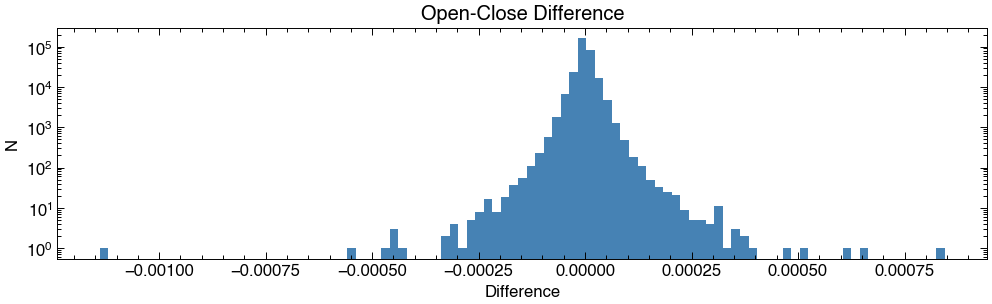

In [ ]:
df = features.compute_open_close_diff(df)

y = df['open_close']
plt.figure(figsize=(12,3))
bins = np.linspace(min(y),max(y),100)
plt.hist(y,bins=bins,color='steelblue')
plt.yscale('log')
plt.title('Open-Close Difference')
plt.xlabel('Difference')
plt.ylabel('N')
plt.savefig('../results/plots/open_close_diff.png')
plt.show()

### Log returns (`log_return`)
- Measure the proportional change in FX prices between consecutive candles, providing the raw, high-frequency price movement signal.  
- Serve as the fundamental building block for derived features like rolling statistics, lagged returns, and volatility measures.  
- Help the model detect immediate market activity and short-term fluctuations that influence future volatility.

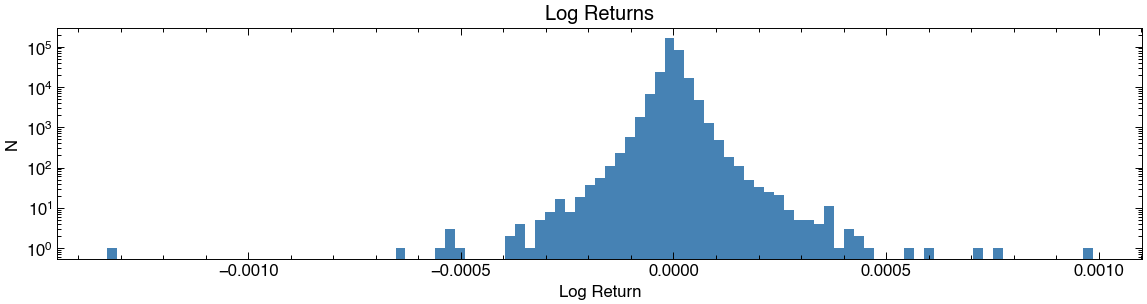

In [ ]:
df = features.compute_log_returns(df)

y = df['log_return']
plt.figure(figsize=(14,3))
bins = np.linspace(min(y),max(y),100)
plt.hist(y,bins=bins,color='steelblue')
plt.yscale('log')
plt.title('Log Returns')
plt.xlabel('Log Return')
plt.ylabel('N')
plt.savefig('../results/plots/log_returns.png')
plt.show()

### Logged lag returns (`log_return_lag_{lag}`)
- Capture recent momentum and directional patterns in FX price movements by including lagged log returns as features.  
- Each lag represents the log return from a previous candle, providing the model with temporal structure.  
- Helps the model identify periods of accelerating or decelerating volatility based on recent price dynamics.
- Lag number corresponds to number of candles, not time.

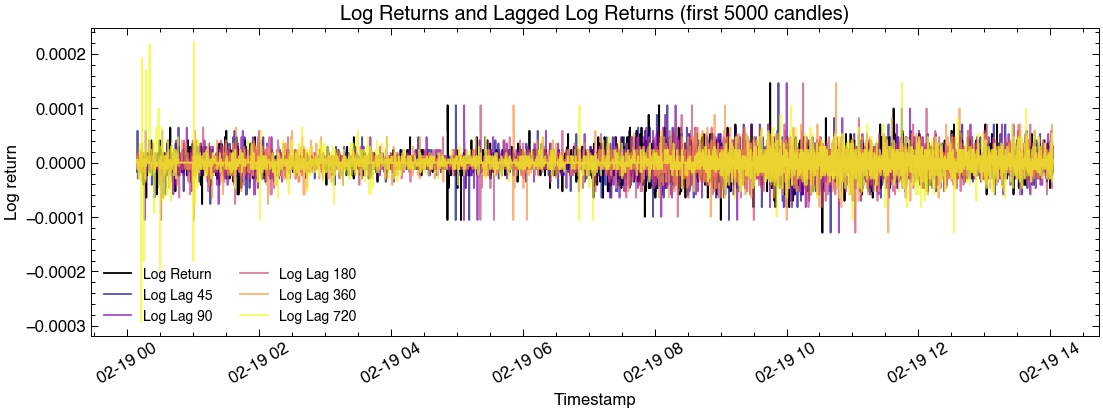

In [ ]:
alpha = 1  # same for both
lag_multipliers = [0.25, 0.5, 1, 2, 4]
lag_seconds = [alpha * f * forecast_horizon for f in lag_multipliers]

df = features.logged_lag_returns(df, lag_seconds=lag_seconds)

time_res = (df['timestamp'].iloc[1] - df['timestamp'].iloc[0]).total_seconds()
lag_steps = [int(ls / time_res) for ls in lag_seconds]

n = 5000
max_lag = max(lag_steps)

# Slice the timestamps and series so that lagged values align
x_plot = df['timestamp'].iloc[max_lag:max_lag+n].values
y0_plot = df['log_return'].iloc[max_lag:max_lag+n]

plt.figure(figsize=(13,4))
plt.step(x_plot, y0_plot, label='Log Return', c='k', ls='-', where='mid')

colors = plt.cm.plasma(np.linspace(0,1,len(lag_steps)))
for indx, lag in enumerate(lag_steps):
    y_lag_plot = df[f'log_return_lag_{lag}'].iloc[max_lag:max_lag+n]
    plt.step(x_plot, y_lag_plot, label=f'Log Lag {lag}', alpha=0.7, color=colors[indx], where='mid')

plt.legend(loc='lower left', ncols=2)
plt.title(f'Log Returns and Lagged Log Returns (first {n} candles)')
plt.xlabel('Timestamp')
plt.ylabel('Log return')
plt.xticks(rotation=30)
plt.savefig('../results/plots/lag_log_returns.png')
plt.show()

### Rolling statistics of Log Returns (`roll_mean`,`roll_std`)
- Capture short-term trends and volatility in recent returns.
- `roll_mean` can indicate temporary trends or drift in price.  
- `roll_std` shows short-term volatility, which is often predictive of future volatility spikes.
- Provide the model with smoothed summaries of past behavior, reducing noise from individual candles.

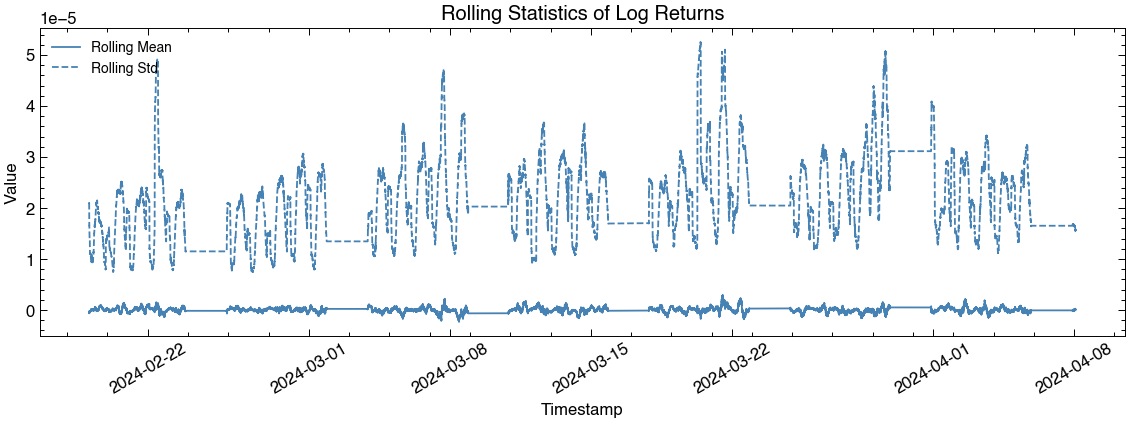

In [ ]:
k = 8
window = k * forecast_horizon
df = features.compute_rolling_stats(df, window_seconds=window)

# Display first few rows to sanity-check
df[['roll_mean', 'roll_std']].head()

# Plot rolling mean and std for the first 500 rows
# x = df.index
x = df['timestamp'].values
y_mean = df['roll_mean']
y_std = df['roll_std']

plt.figure(figsize=(14,4))
plt.plot(x,y_mean,label='Rolling Mean', color='steelblue', ls='-')
plt.plot(x,y_std,label='Rolling Std', color='steelblue', ls='--')
plt.title('Rolling Statistics of Log Returns')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.legend(loc='upper left')
plt.xticks(rotation=30)
plt.savefig('../results/plots/rolling_statistics_log_returns.png')
plt.show()

### Past rolling volatility (`rolling_vol`)
- Computes the standard deviation of the last N candles from time t.
- Provides the most recent computed rolling volatility value as a feature, reflecting the immediate state of market fluctuations.
- Acts as a short-term baseline for predicting future volatility, leveraging the persistence and clustering properties of FX volatility.

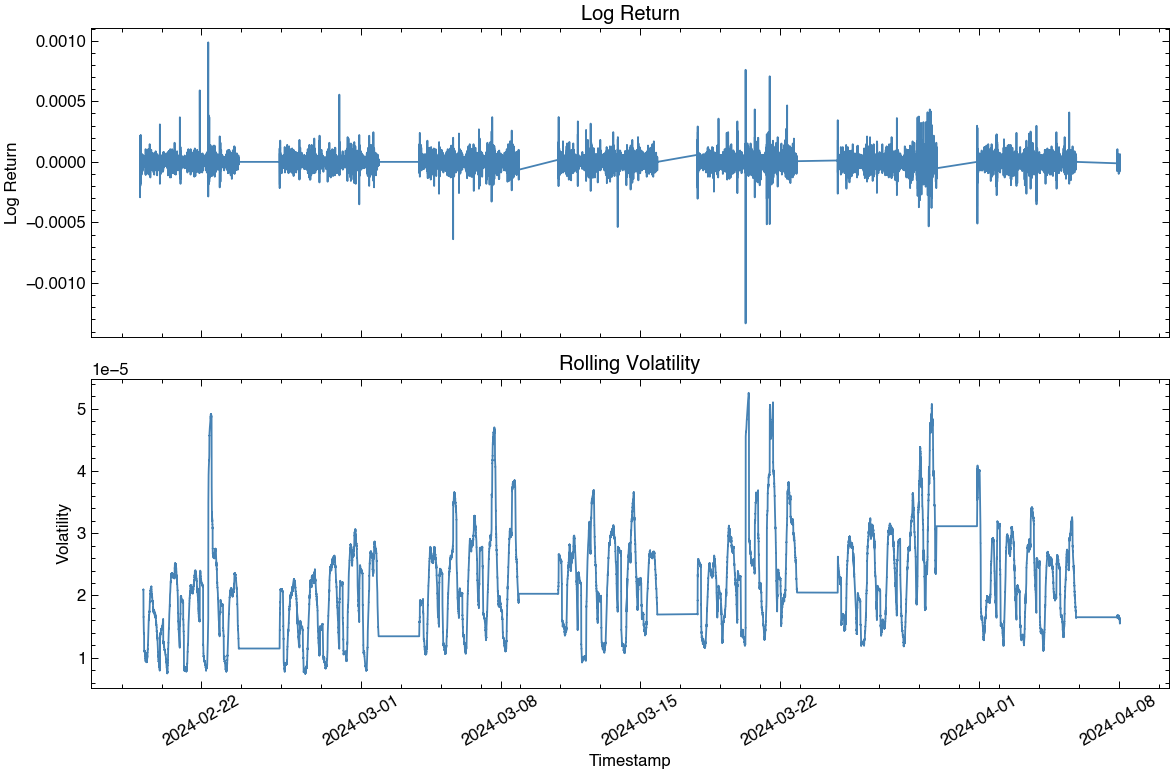

In [ ]:
df = features.compute_rolling_volatility(df,window_seconds=window)

x = df['timestamp'].values
y1 = df['log_return']
y2 = df['rolling_vol']

plt.subplots(2,1,figsize=(12,8),sharex=True)

plt.subplot(2,1,1)
plt.plot(x,y1,c='steelblue')
plt.title('Log Return')
plt.ylabel('Log Return')
plt.xticks(rotation=30)

plt.subplot(2,1,2)
plt.plot(x,y2,c='steelblue')
plt.title('Rolling Volatility')
plt.ylabel('Volatility')
plt.xlabel('Timestamp')
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig('../results/plots/rolling_volatility.png')
plt.show()

### Lagged rolling volatility (`rolling_vol_lag_{lag}`)
- Captures the temporal persistence of volatility by providing delayed snapshots of past volatility levels at horizon-scaled lags.
- Acts as an explicit memory of previous volatility regimes, allowing the model to learn how long elevated or suppressed volatility typically persists in FX markets.
- Lag number corresponds to number of candles, not time.

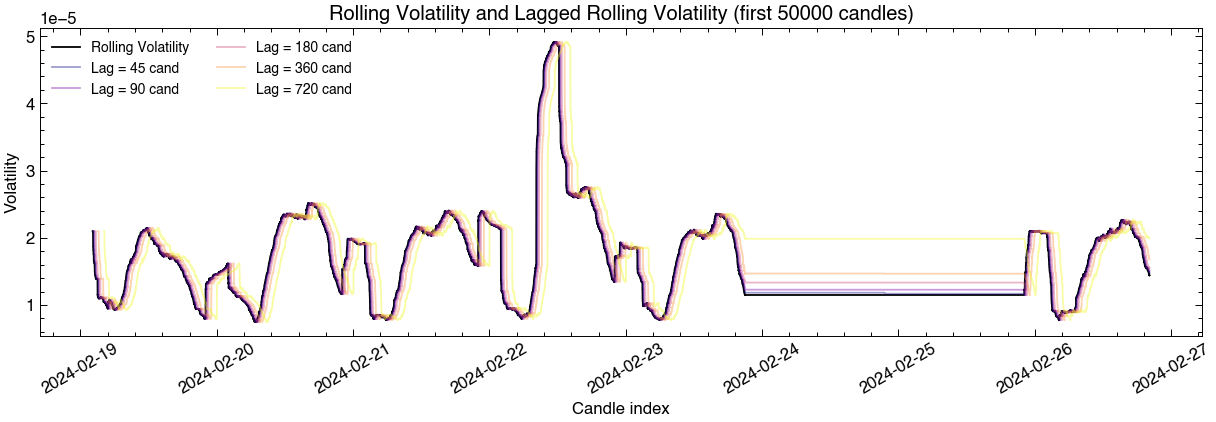

In [ ]:
lag_multipliers = [0.25, 0.5, 1, 2, 4]
lag_seconds = [alpha * f * forecast_horizon for f in lag_multipliers]
df = features.compute_lagged_rolling_volatility(df,lag_seconds=lag_seconds,window_seconds=window)

time_res = (df['timestamp'].iloc[1] - df['timestamp'].iloc[0]).total_seconds()
lag_steps = [int(ls / time_res) for ls in lag_seconds]

# max_index = 50000
# x = df.index[:max_index]
# y0 = df['rolling_vol'].iloc[:max_index]

plt.figure(figsize=(15,4))

max_lag = max(lag_steps)
n = 50000
x_plot = df['timestamp'].iloc[max_lag:max_lag+n].values
y0_plot = df['rolling_vol'].iloc[max_lag:max_lag+n]

plt.step(x_plot, y0_plot, label='Rolling Volatility', c='k', where='mid')

colors = plt.cm.plasma(np.linspace(0,1,len(lag_steps)))
for indx, lag in enumerate(lag_steps):
    y_lag_plot = df[f'rolling_vol_lag_{lag}'].iloc[max_lag:max_lag+n]
    plt.step(x_plot, y_lag_plot, label=f'Lag = {lag} cand', alpha=0.4, color=colors[indx], where='mid')

# colors = plt.cm.plasma(np.linspace(0,1,len(lag_steps)))
# for indx, lag in enumerate(lag_steps):
#     plt.step(x, df[f'rolling_vol_lag_{lag}'].iloc[:max_index], label=f'Rolling Vol Lag {lag}', alpha=0.4, color=colors[indx], where='mid')

plt.legend(loc='upper left',ncols=2)
plt.title(f'Rolling Volatility and Lagged Rolling Volatility (first {n} candles)')
plt.xlabel('Candle index')
plt.ylabel('Volatility')
plt.xticks(rotation=30)
plt.savefig('../results/plots/lag_rolling_volatility.png')
plt.show()


### Multi-window rolling volatility (`rolling_vol_{w}_cand`)
- Computes rolling volatility over multiple window lengths scaled to the forecast horizon, capturing volatility dynamics across short-, medium-, and longer-term timescales.
- Helps the model combine fast-reacting and slow-moving volatility signals, improving robustness to regime changes and reducing sensitivity to noise in any single window.
- Window number corresponds to number of candles, not time.

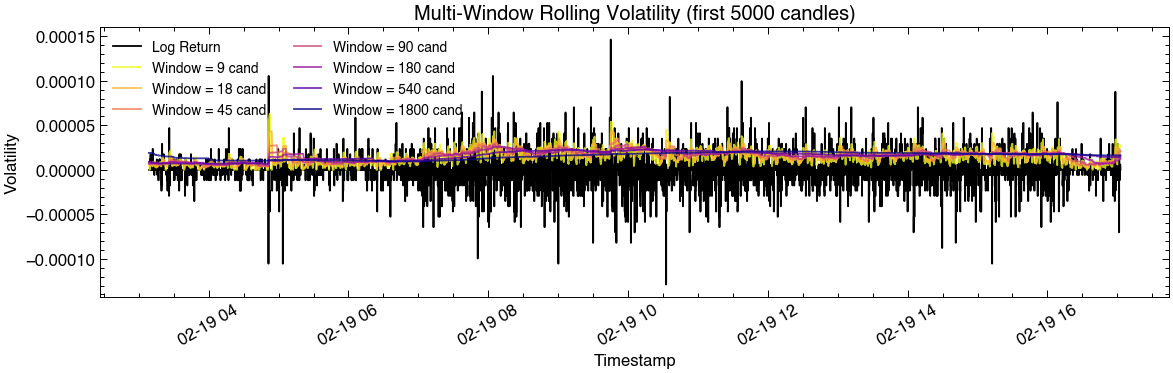

In [ ]:
window_multipliers = [0.05, 0.1, 0.25, 0.5, 1, 3, 10]  # short, medium, long

df = features.compute_multi_window_rolling_vol(df, forecast_horizon, window_multipliers, base_col='log_return')

# Compute window sizes in candles
window_candles_list = [max(int(k * forecast_horizon / time_res), 1) for k in window_multipliers]

# Find the maximum window length for alignment
max_window = max(window_candles_list)

# Slice data so all rolling vol series start at the first valid point
x_plot = df['timestamp'].iloc[max_window:max_window+n].values  # e.g., first 5000 points
y_return = df['log_return'].iloc[max_window:max_window+n]

plt.figure(figsize=(12,4))
plt.step(x_plot, y_return, label='Log Return', color='k', alpha=1, where='mid')

colors = plt.cm.plasma_r(np.linspace(0,1,len(window_multipliers)))
for indx, window_candles in enumerate(window_candles_list):
    y_vol = df[f'rolling_vol_{window_candles}_cand'].iloc[max_window:max_window+n]
    plt.plot(x_plot, y_vol, label=f'Window = {window_candles} cand', color=colors[indx], alpha=0.8)

plt.xlabel('Timestamp')
plt.ylabel('Volatility')
plt.title(f'Multi-Window Rolling Volatility (first {n} candles)')
plt.xticks(rotation=30)
plt.legend(loc='upper left', ncols=2)
plt.tight_layout()
plt.savefig('../results/plots/multi_window_rolling_volatility.png')
plt.show()

### Intra-day Seasonality (`tod_sin`,`tod_cos`)
- Captures systematic patterns in volatility or returns that recur at specific times of day (e.g., market open/close, London–New York overlap).  
- Provides the model with a "time of day context"i.
- Helps the model account for predictable temporal effects that are not explained by recent price dynamics or rolling volatility, improving short- to medium-term forecast accuracy.

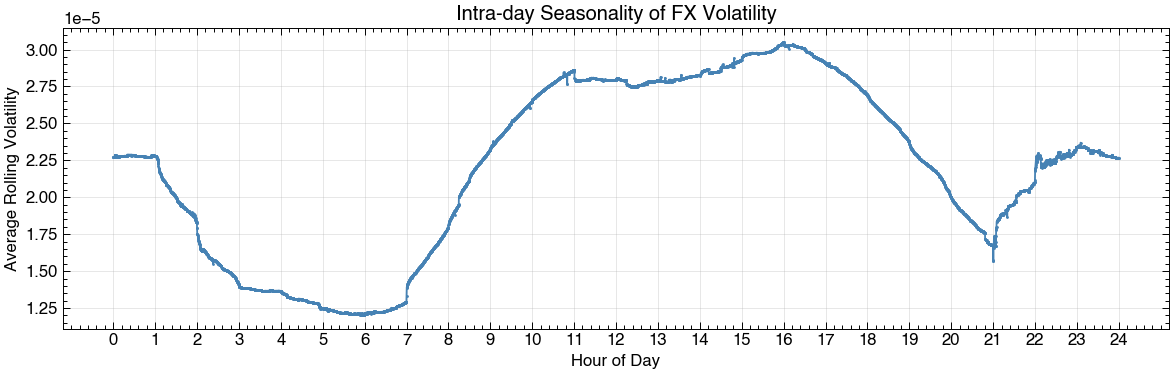

In [ ]:
df = features.compute_intraday_seasonality(df)

seconds_in_day = 24*60*60
time_of_day_sec = df['timestamp'].dt.hour*3600 + df['timestamp'].dt.minute*60 + df['timestamp'].dt.second
df['hour_of_day'] = time_of_day_sec / 3600  # 0-24 hours

# Optionally, aggregate rolling_vol by hour of day to see average pattern
hourly_vol = df.groupby('hour_of_day')['rolling_vol'].mean()

plt.figure(figsize=(12,4))
plt.plot(hourly_vol.index, hourly_vol.values, marker='o',markersize=1,c='steelblue')
plt.xlabel('Hour of Day')
plt.ylabel('Average Rolling Volatility')
plt.title('Intra-day Seasonality of FX Volatility')
plt.grid(alpha=0.3)
plt.xticks(range(0,25))
plt.tight_layout()
plt.savefig('../results/plots/intraday_seasonality.png')
plt.show()

### Volatility slope (`vol_slope`)
- Measures the recent trend in volatility by capturing whether volatility is increasing or decreasing over a short, horizon-aligned window.
- Helps the model anticipate volatility regime transitions by providing directional information about upcoming changes in volatility.

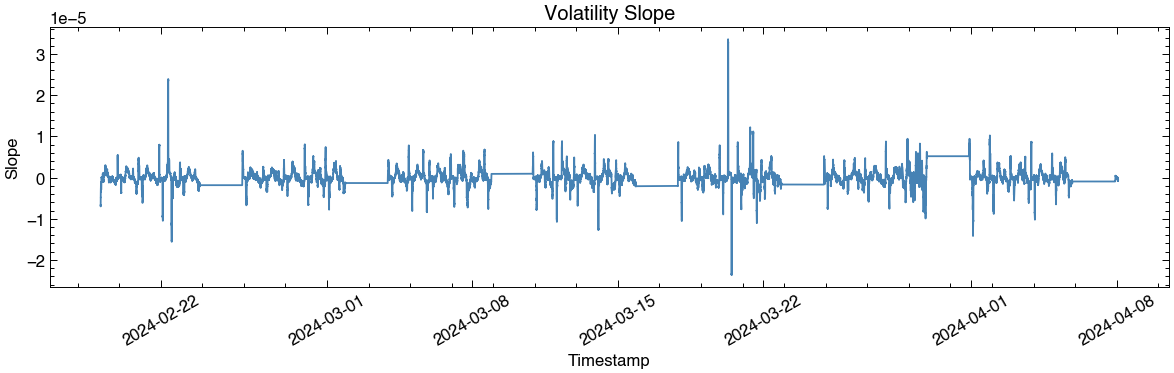

In [ ]:
df = features.compute_volatility_slope(df,forecast_horizon)

plt.figure(figsize=(12,4))
plt.plot(df['timestamp'].values,df['vol_slope'],label='vol_slope',c='steelblue')
plt.title('Volatility Slope')
plt.ylabel('Slope')
plt.xlabel('Timestamp')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../results/plots/volatility_slope.png')
plt.show()

### Volatility z-score (`vol_zscore`)
- Measures how extreme the current volatility level is relative to its recent regime (defined over a horizon-aligned window), providing scale-aware context.
- Helps the model distinguish between normal fluctuations and tail regimes, improving its ability to predict the *magnitude* of future volatility rather than just its direction.

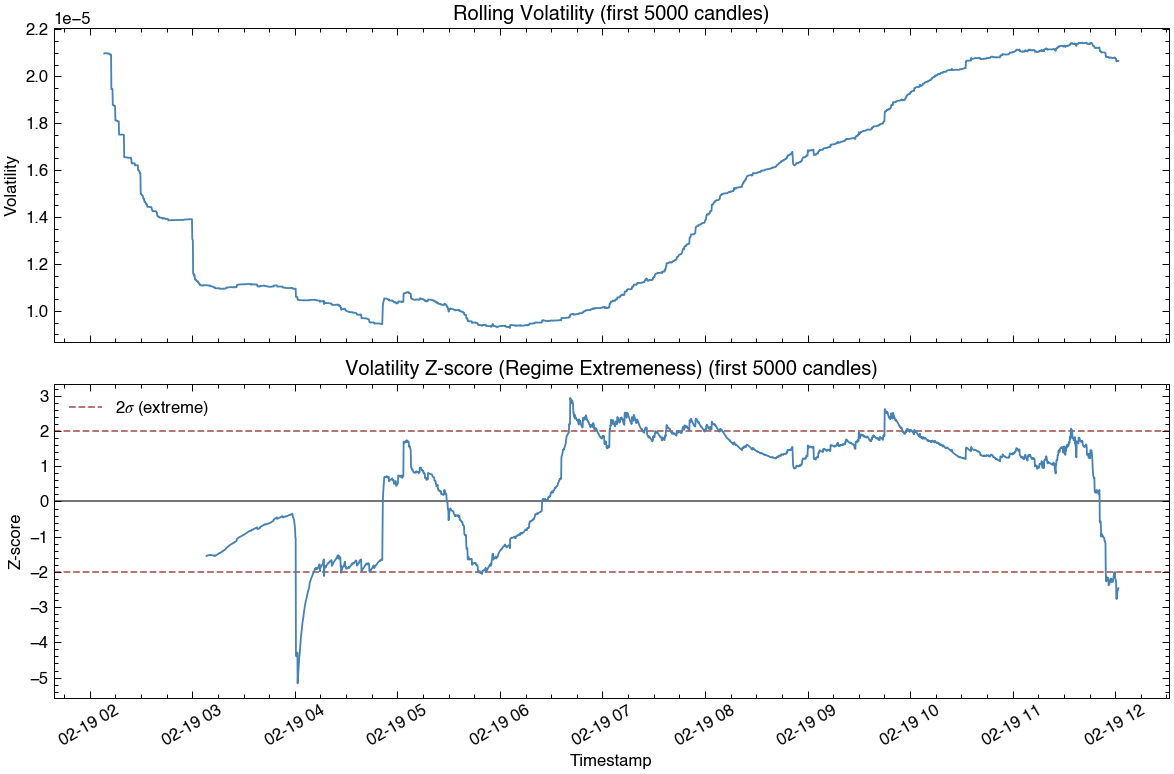

In [ ]:
z_window_multiplier = 2
df = features.compute_volatility_zscore(df,forecast_horizon,z_window_multiplier)

x = df['timestamp'].values[:n]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Rolling volatility
axes[0].plot(x, df['rolling_vol'].iloc[:n], c='steelblue')
axes[0].set_ylabel('Volatility')
axes[0].set_title(f'Rolling Volatility (first {n} candles)')

# Volatility z-score
axes[1].plot(x, df['vol_zscore'].iloc[:n], color='steelblue', zorder=4)
axes[1].axhline(0, color='k', alpha=0.6)
axes[1].axhline(2, color='maroon', ls='--', alpha=0.6, label=r'2$\sigma$ (extreme)')
axes[1].axhline(-2, color='maroon', ls='--', alpha=0.6)
axes[1].set_ylabel('Z-score')
axes[1].set_title(f'Volatility Z-score (Regime Extremeness) (first {n} candles)')
axes[1].set_xlabel('Timestamp')
axes[1].legend(loc='upper left',fontsize=12)

plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../results/plots/volatility_zscore.png')
plt.show()

## Target
- Target of the candle data that we are aiming to predict using ML.

### Future rolling volatility (`rolling_future_vol`)

- Future rolling volatility shows strong temporal persistence.
- Peaks in future volatility align with peaks in past rolling volatility.
- This reflects volatility clustering: periods of high volatility tend to be followed by high volatility.
- The target is computed strictly from data in the interval t → t+H, so this alignment is causal, not information leakage.
- This validates that past volatility contains predictive information about future volatility.
- The model’s task is therefore to learn the mapping from past volatility regimes to future volatility magnitude.
- Any predictive power beyond this persistence will be captured by the non-linear structure of the gradient boosting model.

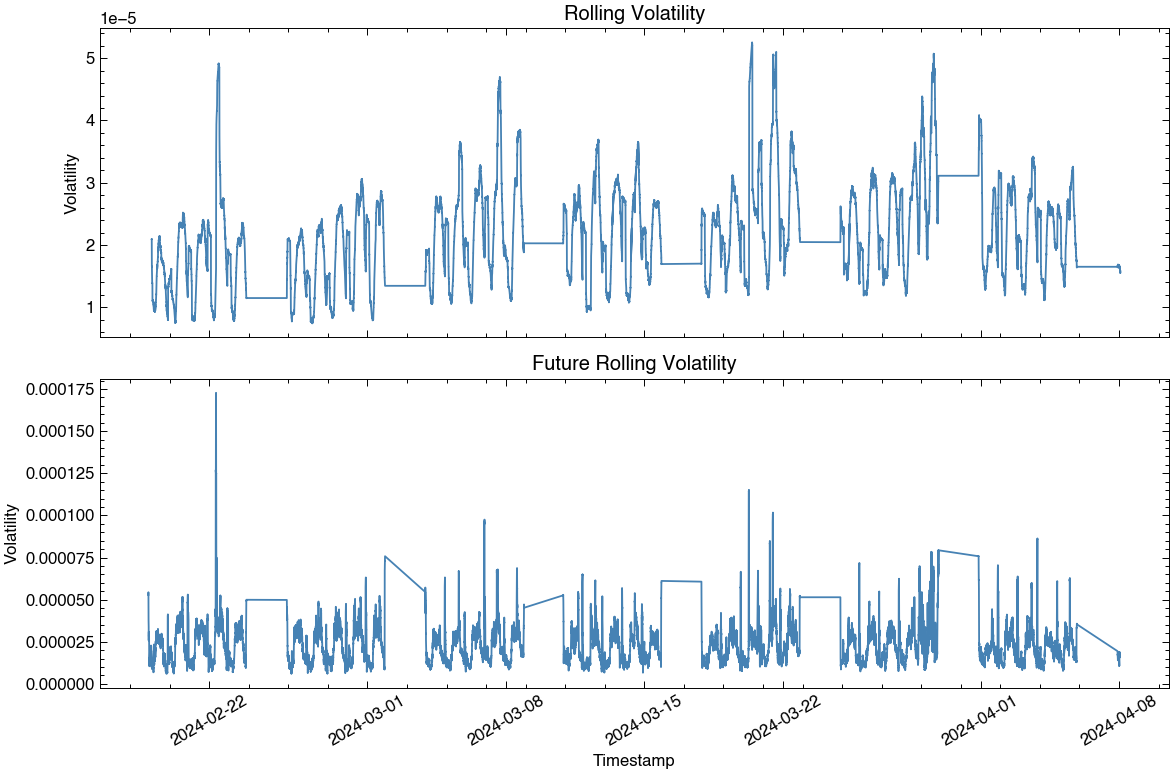

In [ ]:
df = df.copy()
df = features.compute_future_rolling_volatility(df,horizon=forecast_horizon)

eps = 1e-8 #volatility can be too close to zero
df['rolling_log_future_vol'] = np.log(df['rolling_future_vol'] + eps)

x = df['timestamp'].values
y1 = df['rolling_vol']
y2 = df['rolling_future_vol']

plt.subplots(2,1,figsize=(12,8),sharex=True)
plt.subplot(2,1,1)
plt.title('Rolling Volatility')
plt.plot(x,y1,c='steelblue')
plt.ylabel('Volatility')
plt.subplot(2,1,2)
plt.title('Future Rolling Volatility')
plt.plot(x,y2,c='steelblue')
plt.ylabel('Volatility')
plt.xlabel('Timestamp')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../results/plots/future_rolling_volatility.png')
plt.show()

## Machine Learning

### 1. Split Data

We split the dataset chronologically to preserve temporal dependencies:
- Training set: used to fit the Gradient Boosting model
- Test set: used to evaluate out-of-sample predictive performance
- Validation set: used to monitor model performance on unseen data

Features: past rolling volatility (`rolling_vol`)  
Target: forward-looking volatility (`rolling_future_vol`)


In [95]:
time_res = (df['timestamp'].iloc[1] - df['timestamp'].iloc[0]).total_seconds()
lag_steps = [int(ls / time_res) for ls in lag_seconds]
window_candles_list = [max(int(k * forecast_horizon / time_res), 1) for k in window_multipliers]

# feature_cols = ['rolling_vol', 'roll_mean', 'roll_std', 'high_low_range', 'log_return', 'open_close'] + \
#     [f'log_return_lag{i}' for i in range(1, n_lags+1)] + \
#         [f'rolling_vol_lag_{lag}' for lag in lag_steps] + \
#         [f'rolling_vol_{w}_cand' for w in window_candles_list]

feature_cols = ['rolling_vol'] + [f'rolling_vol_lag_{lag}' for lag in lag_steps] + \
    [f'rolling_vol_{w}_cand' for w in window_candles_list] + ['tod_sin', 'tod_cos', 'vol_of_vol'] + ['vol_slope'] + ['vol_zscore']

X_train, X_test, y_train, y_test = model.split_data(df, feature_cols, target_col='rolling_log_future_vol', train_frac=0.8)

val_frac = 0.1
val_index = int(len(X_train) * (1 - val_frac))
X_tr, X_val = X_train[:val_index], X_train[val_index:]
y_tr, y_val = y_train[:val_index], y_train[val_index:]

print(f"Training samples: {len(X_tr)}, Test samples: {len(X_test)}, Validation samples: {len(X_val)}")

Training samples: 213797, Test samples: 59389, Validation samples: 23756


### 2. Train Model

We train a Gradient Boosting Machine to predict forward-looking volatility:
- Uses features from past rolling volatility
- Trains on a training set while validating against a validation set in order to find the optimal number of boosting rounds.
- Each boosting round improves the prediction slightly by reducing the residuals from previous rounds.

Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 0.257618	valid_0's l2: 0.0663669
[100]	valid_0's rmse: 0.25646	valid_0's l2: 0.0657717
Did not meet early stopping. Best iteration is:
[60]	valid_0's rmse: 0.254839	valid_0's l2: 0.0649431
{'valid_0': OrderedDict({'rmse': [0.39657170922017526, 0.3753497485686435, 0.3571199888123772, 0.3409197961301746, 0.3278691351044408, 0.318743140745977, 0.3089867356141453, 0.30103605313761017, 0.29367995942318365, 0.2881511116904946, 0.2840478932637263, 0.2804952389864637, 0.27798639186776736, 0.27559199909569226, 0.274038789289476, 0.2724559028176741, 0.2708539570791057, 0.2697048491845219, 0.2690197568096617, 0.2655024688009757, 0.265042570527428, 0.26206339952029567, 0.2619816126882242, 0.26215790471034434, 0.2599388372086179, 0.260004581009309, 0.26027332666904374, 0.2584649653525779, 0.25857646555190444, 0.25847896050011965, 0.2585136958878721, 0.25879050510522944, 0.259260805555821, 0.2589741821649081, 0.2590701

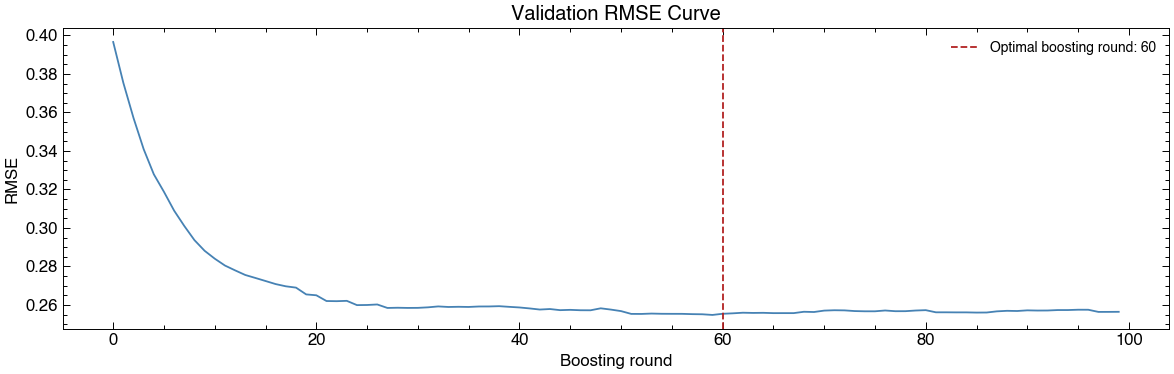

In [311]:
gb_params = {
    'n_estimators': 100,      
    'learning_rate': 0.1,     
    'max_depth': 3,            
    'random_state': 42,        
    # Optional LightGBM-specific speed-ups:
    'num_leaves': 31,          # default leaf-wise growth
    'feature_fraction': 0.9,   # subsample features per tree
    'bagging_fraction': 0.8,   # subsample rows per iteration
    'bagging_freq': 5,         # perform bagging every 5 rounds
    'verbosity': -1
}

# Now you can train the model on X, y
ml_model, evals_result = model.train_model(X_tr,y_tr,X_val,y_val,**gb_params)

plt.figure(figsize=(12,4))
plt.plot(evals_result['valid_0']['rmse'], color='steelblue')
plt.axvline(ml_model.best_iteration_, color='firebrick', ls='--', label=f'Optimal boosting round: {ml_model.best_iteration_}')
plt.xlabel('Boosting round')
plt.ylabel('RMSE')
plt.title('Validation RMSE Curve')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 3. Re-train Model
- Trains again on the training + validation sets using optimised number of boosting rounds.
- Uses trained model to predict aggregate volatility over the specified horizon

In [ ]:
X_train_full = np.vstack([X_tr, X_val])
y_train_full = np.hstack([y_tr, y_val])

ml_model = model.retrain_model(X_train_full,y_train_full,ml_model)

Training RMSE: 0.223668
Training MAE: 0.159621


/Users/dominictaylor/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### 4. Evaluate Model

We evaluate the model on the test set using:
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)

Compare predicted and actual forward volatility on the test set:
- Peaks in prediction should align with realised volatility peaks
- Confirms model is capturing temporal patterns in volatility

/Users/dominictaylor/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


RMSE: 0.310603
MAE: 0.226816
58668


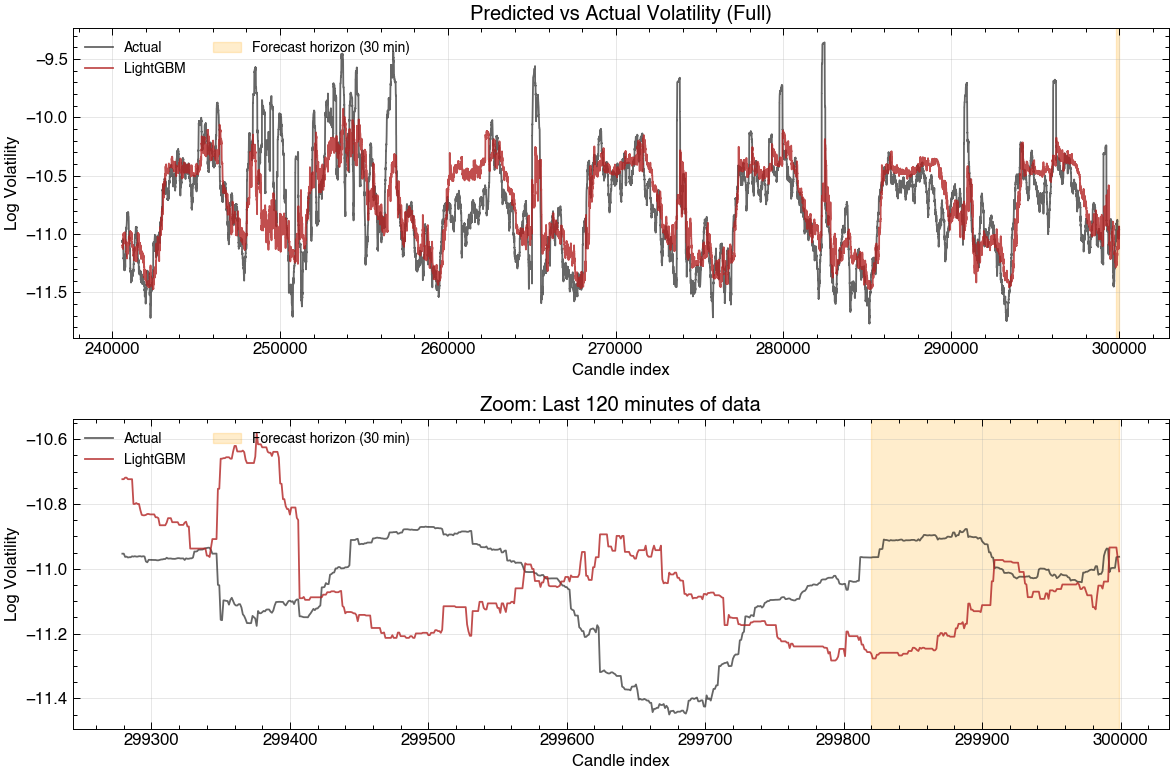

In [ ]:
y_pred_log, y_pred_vol, rmse_log, mae_log = model.evaluate_model(ml_model, X_test, y_test)
print(f"RMSE: {rmse_log:.6f}")
print(f"MAE: {mae_log:.6f}")

time_res = (df['timestamp'].iloc[1] - df['timestamp'].iloc[0]).total_seconds()
H = int(forecast_horizon / time_res)

actual_color = 'k'
model_color = 'firebrick'
baseline_color = 'steelblue'
horizon_color = 'orange'
actual_alpha = 0.6
model_alpha = 0.8
baseline_alpha = 0.5

# Reindex x-axis for the test set
# x_test = df['timestamp'].iloc[-len(y_test):].values
x_test = df.index[-len(y_test):]

# Plot
fig, ax = plt.subplots(2, 1, figsize=(12,8))

# Full series
ax[0].plot(x_test, y_test, label='Actual', color=actual_color, alpha=actual_alpha)
ax[0].plot(x_test, y_pred_log, label='LightGBM', color=model_color, alpha=model_alpha)
ax[0].axvspan(x_test[-H], x_test[-1], color=horizon_color, alpha=0.2, label='Forecast horizon (%s min)'%str(int(forecast_horizon/60)))

ax[0].set_xlabel('Candle index')
# ax[0].set_xlabel('Timestamp')
ax[0].set_ylabel('Log Volatility')
ax[0].set_title('Predicted vs Actual Volatility (Full)')
ax[0].legend(loc='upper left',ncols=2)
ax[0].grid(True,alpha=0.3)
ylims = ax[0].get_ylim()

# Desired zoom duration in seconds (e.g., 5×forecast_horizon)
zoom_seconds = 4 * forecast_horizon

# Compute elapsed time from the last timestamp
end_time = x_test[-1]
start_time = end_time - np.timedelta64(int(zoom_seconds), 's')

# Find the index in x_test that is the first >= start_time
start_zoom_idx = np.searchsorted(x_test, start_time)

# start_zoom_idx = np.arange(0,len(y_test))[-1]-(4*H)
# print(start_zoom_idx)

# Slice data for zoomed view
x_zoom = x_test[start_zoom_idx:]
y_zoom = y_test[start_zoom_idx:]
y_pred_zoom = y_pred_log[start_zoom_idx:]

ax[1].plot(x_zoom, y_zoom, label='Actual', color=actual_color, alpha=actual_alpha)
ax[1].plot(x_zoom, y_pred_zoom, label='LightGBM', color=model_color, alpha=model_alpha)
ax[1].axvspan(x_zoom[-H], x_zoom[-1], color=horizon_color, alpha=0.2, label='Forecast horizon (%s min)'%str(int(forecast_horizon/60)))

# ax[1].set_xlabel('Date/Time')
ax[1].set_xlabel('Candle index')
ax[1].set_ylabel('Log Volatility')
ax[1].set_title(f'Zoom: Last {zoom_seconds/60:.0f} minutes of data')
ax[1].legend(loc='upper left',ncols=2)
ax[1].grid(True,alpha=0.3)
# ax[1].set_xticks(ticks='major',rotation=30)
# plt.setp(ax[0].get_xticklabels(), rotation=30)
# plt.setp(ax[1].get_xticklabels(), rotation=30)
plt.tight_layout()
plt.savefig('../results/plots/predicted_vs_actual_volatility.png')
plt.show()

# Model Performance Evaluation

This section evaluates the LightGBM volatility forecasting model against multiple baselines and visualizes feature importance.

## Baselines

We compare the model against three naive volatility baselines:

1. **Lagged baseline**: uses the previous rolling volatility (`rolling_vol`) as the forecast.  
2. **Short-window baseline**: uses a short rolling window of past volatility.  
3. **Medium-window baseline**: uses a medium rolling window of past volatility.  

All baselines are transformed into log-space for fair comparison with the LightGBM model predictions.

## Metrics

We compute:

- **RMSE (Root Mean Squared Error)** in log-volatility space  
- **MAE (Mean Absolute Error)** in log-volatility space  
- **Percentage improvement** of the LightGBM model over each baseline  

This quantifies how much the model reduces prediction error compared to simple heuristics.

## Visualizations

1. **Full series plot**: Shows the actual volatility, LightGBM predictions, and all three baselines over the test set.  
2. **Zoomed-in view**: Focuses on the last few forecast horizons to highlight model performance on short-term volatility spikes.  
3. **Forecast horizon highlight**: Orange shaded region indicates the prediction horizon for clarity.  
4. **Feature importance heatmap**: Displays which features the LightGBM model relied on most, helping interpret model decisions.

> These visualizations allow both quantitative and intuitive assessment of model performance and highlight the advantage of using machine learning over naive volatility estimates.


Baselines: rolling_vol_lag_45 rolling_vol_9_cand rolling_vol_90_cand rolling_vol_1800_cand 



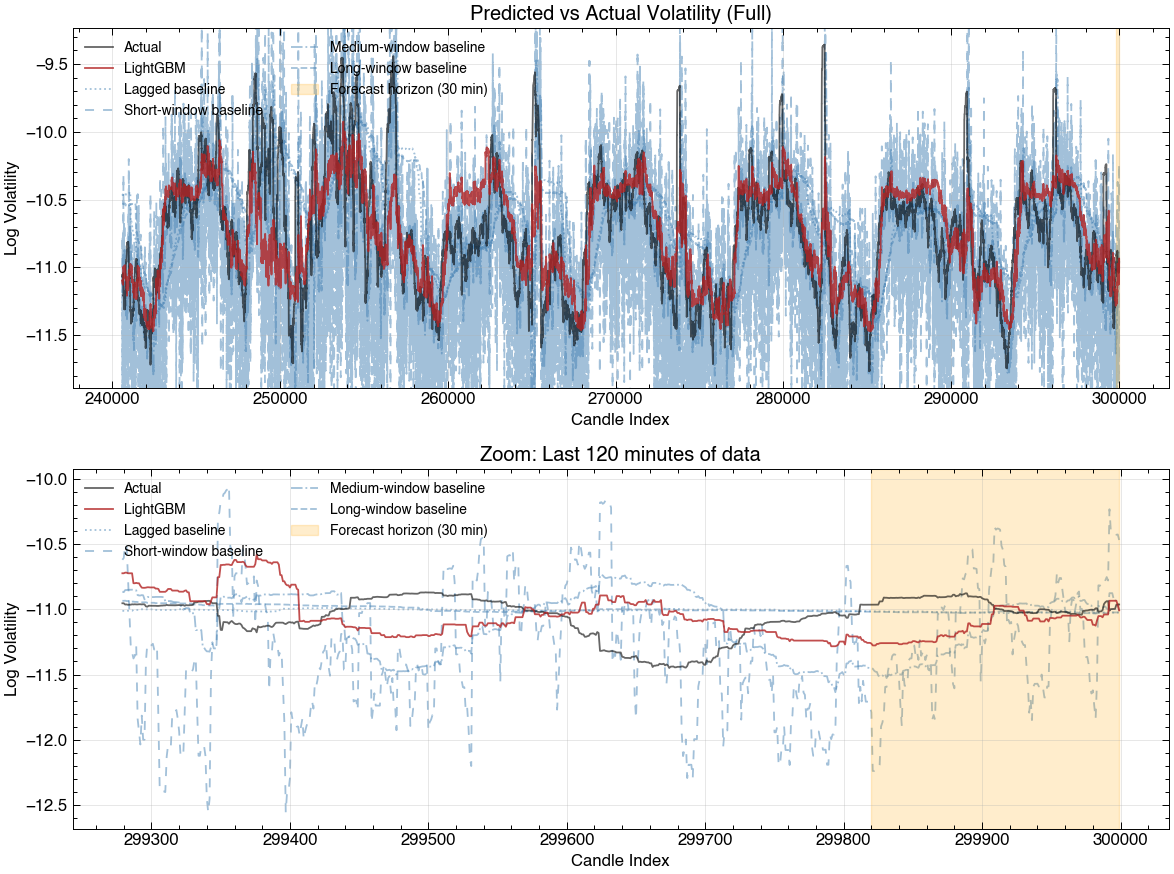

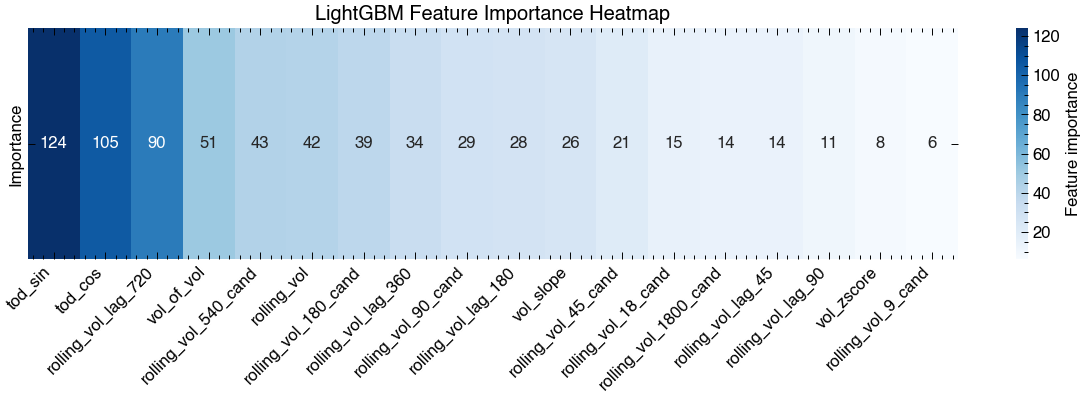

In [294]:
# Ensure y_test and features are float arrays
y_test = np.array(y_test, dtype=float)

# Compute baseline predictions
eps = 1e-8
baselines = {}

# Lagged baseline
lagged_col = [c for c in feature_cols if 'lag' in c][0]
baselines['Lagged'] = np.log(X_test[:, feature_cols.index(lagged_col)] + eps)

# Short / Medium / Long rolling vol baselines
rolling_cols = [c for c in feature_cols if 'rolling_vol_' in c and 'cand' in c]
baselines['Short-window']  = np.log(X_test[:, feature_cols.index(rolling_cols[0])] + eps)
baselines['Medium-window'] = np.log(X_test[:, feature_cols.index(rolling_cols[len(rolling_cols)//2])] + eps)
baselines['Long-window']   = np.log(X_test[:, feature_cols.index(rolling_cols[-1])] + eps)
print('Baselines:',lagged_col,rolling_cols[0],rolling_cols[len(rolling_cols)//2],rolling_cols[-1],"\n")

baseline_style = {
    'Lagged': ':',
    'Short-window': (0, (5, 5)),
    'Medium-window': '-.',
    'Long-window': '--'  # custom dash pattern
}
actual_color = 'k'
model_color = 'firebrick'
baseline_color = 'steelblue'
horizon_color = 'orange'
actual_alpha = 0.6
model_alpha = 0.8
baseline_alpha = 0.5

# Reindex x-axis for the test set
# x_test = df['timestamp'].iloc[-len(y_test):].values
x_test = df.index[-len(y_test):]

# Plot
fig, ax = plt.subplots(2, 1, figsize=(12,9))

# Full series
ax[0].plot(x_test, y_test, label='Actual', color=actual_color, alpha=actual_alpha, zorder=3)
ax[0].plot(x_test, y_pred_log, label='LightGBM', color=model_color, alpha=model_alpha, zorder=3)

for name, pred in baselines.items():
    ls = baseline_style[name]
    ax[0].plot(x_test, pred, label=name + ' baseline', color=baseline_color, linestyle=ls, alpha=baseline_alpha, zorder=1)

# Shade forecast horizon
ax[0].axvspan(x_test[-H], x_test[-1], color=horizon_color, alpha=0.2, label='Forecast horizon (%s min)'%str(int(forecast_horizon/60)))

ax[0].set_xlabel('Candle Index')
# ax[0].set_xlabel('Timestamp')
ax[0].set_ylabel('Log Volatility')
ax[0].set_title('Predicted vs Actual Volatility (Full)')
ax[0].legend(loc='upper left',ncols=2)
ax[0].grid(True,alpha=0.3)
ax[0].set_ylim(ylims[0],ylims[1])

# Desired zoom duration in seconds (e.g., 5×forecast_horizon)
zoom_seconds = 4 * forecast_horizon

# # Compute elapsed time from the last timestamp
# end_time = x_test[-1]
# start_time = end_time - np.timedelta64(int(zoom_seconds), 's')

# # Find the index in x_test that is the first >= start_time
# start_zoom_idx = np.searchsorted(x_test, start_time)

start_zoom_idx = np.arange(0,len(y_test))[-1]-(4*H)

# Slice data for zoomed view
x_zoom = x_test[start_zoom_idx:]
y_zoom = y_test[start_zoom_idx:]
y_pred_zoom = y_pred_log[start_zoom_idx:]

ax[1].plot(x_zoom, y_zoom, label='Actual', color=actual_color, alpha=actual_alpha, zorder=3)
ax[1].plot(x_zoom, y_pred_zoom, label='LightGBM', color=model_color, alpha=model_alpha, zorder=3)

for name, pred in baselines.items():
    ls = baseline_style[name]
    ax[1].plot(x_zoom, pred[start_zoom_idx:], label=name + ' baseline', color=baseline_color, linestyle=ls, alpha=baseline_alpha, zorder=1)

# Forecast horizon shading: last H candles
ax[1].axvspan(x_zoom[-H], x_zoom[-1], color=horizon_color, alpha=0.2, label='Forecast horizon (%s min)'%str(int(forecast_horizon/60)))

ax[1].set_xlabel('Candle Index')
# ax[1].set_xlabel('Date/Time')
ax[1].set_ylabel('Log Volatility')
ax[1].set_title(f'Zoom: Last {zoom_seconds/60:.0f} minutes of data')
ax[1].legend(loc='upper left',ncols=2)
ax[1].grid(True,alpha=0.3)
# plt.setp(ax[0].get_xticklabels(), rotation=30)
# plt.setp(ax[1].get_xticklabels(), rotation=30)
plt.tight_layout()
plt.savefig('../results/plots/predicted_vs_actual_volatility_baseline_compare.png')
plt.show()

#Feature Importance Heatmap
importances = ml_model.feature_importances_
feature_names = feature_cols

# Sort features by importance
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(15, 3))
sns.heatmap(
    np.expand_dims(importances[sorted_idx], axis=0),
    annot=True,
    fmt=".0f",
    cmap="Blues",
    yticklabels=["Importance"],
    xticklabels=np.array(feature_names)[sorted_idx],
    cbar_kws={'label': 'Feature importance'}
)
plt.xticks(rotation=45, ha='right')
plt.title("LightGBM Feature Importance Heatmap")
plt.savefig('../results/plots/feature_importance_heatmap.png')
plt.show()

### Comparison of Baselines vs LightGBM Model

Performance comparison (log-volatility space):

Lagged baseline: RMSE=0.457046, MAE=0.360743
  -> LightGBM improvement: RMSE 32.04%, MAE 37.13%

Short-window baseline: RMSE=0.613800, MAE=0.453545
  -> LightGBM improvement: RMSE 49.40%, MAE 49.99%

Medium-window baseline: RMSE=0.383743, MAE=0.265847
  -> LightGBM improvement: RMSE 19.06%, MAE 14.68%

Long-window baseline: RMSE=0.462730, MAE=0.369352
  -> LightGBM improvement: RMSE 32.88%, MAE 38.59%



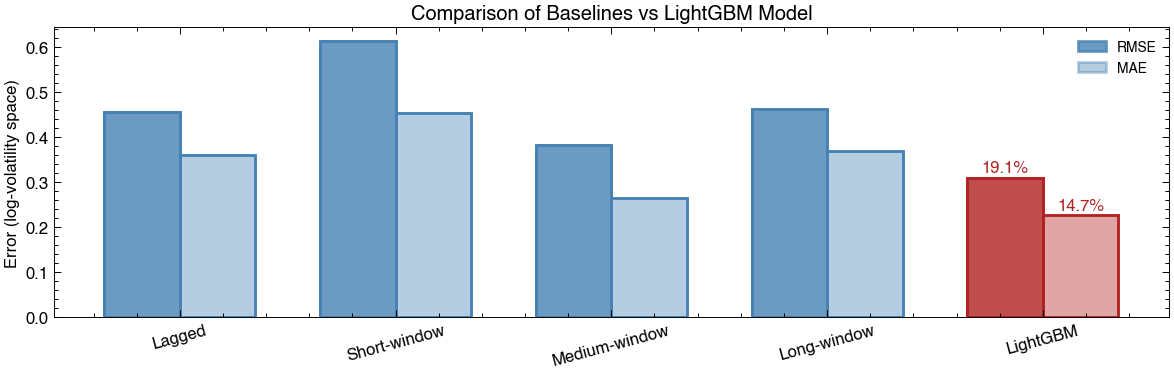

In [295]:
#Model performance prints
print("Performance comparison (log-volatility space):\n")
for name, pred in baselines.items():
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    rmse_improve = 100 * (rmse - rmse_log) / rmse
    mae_improve  = 100 * (mae - mae_log) / mae
    print(f"{name} baseline: RMSE={rmse:.6f}, MAE={mae:.6f}")
    print(f"  -> LightGBM improvement: RMSE {rmse_improve:.2f}%, MAE {mae_improve:.2f}%\n")

# Compute baseline metrics
baseline_names = list(baselines.keys())
baseline_rmse = []
baseline_mae = []
rmse_improve = []
mae_improve = []

for name, pred in baselines.items():
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    baseline_rmse.append(rmse)
    baseline_mae.append(mae)
    
    # % improvement over ML model
    rmse_improve.append(100 * (rmse - rmse_log) / rmse)
    mae_improve.append(100 * (mae - mae_log) / mae)

# Add ML model values
all_names = baseline_names + ['LightGBM']
all_rmse = baseline_rmse + [rmse_log]
all_mae  = baseline_mae + [mae_log]

x = np.arange(len(all_names))  # positions for bars
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(12,4))

model_color = 'firebrick'
baseline_color = 'steelblue'
rmse_alpha = 0.8
mae_alpha = 0.4

# Plot RMSE bars
for i, val in enumerate(all_rmse):
    if all_names[i] == 'LightGBM':
        color = model_color
    else:
        color = baseline_color
    alpha = rmse_alpha
    # color = 'green' if all_names[i] == 'LightGBM' else 'red'
    # alpha = 0.8 if all_names[i] == 'LightGBM' else 0.4
    ax.bar(x[i] - width/2, val, width, color=color, alpha=alpha, edgecolor=color, lw=2, label='RMSE' if i==0 else "")
    ax.bar(x[i] - width/2, val, width, color='none', alpha=1, edgecolor=color, lw=2)

# Plot MAE bars
for i, val in enumerate(all_mae):
    # color = 'green' if all_names[i] == 'LightGBM' else 'orange'
    # alpha = 0.8 if all_names[i] == 'LightGBM' else 0.4
    if all_names[i] == 'LightGBM':
        color = model_color
    else:
        color = baseline_color
    alpha = mae_alpha
    ax.bar(x[i] + width/2, val, width, color=color, alpha=alpha, edgecolor=color, lw=2, label='MAE' if i==0 else "")
    ax.bar(x[i] + width/2, val, width, color='none', alpha=1, edgecolor=color, lw=2)

# Add % improvement annotations for ML model (vs Medium-window baseline)
idx_medium = baseline_names.index('Medium-window')
ax.text(x[-1] - width/2, all_rmse[-1]+0.005, f"{rmse_improve[idx_medium]:.1f}%", ha='center', va='bottom', fontsize=12, color=model_color)
ax.text(x[-1] + width/2, all_mae[-1]+0.005, f"{mae_improve[idx_medium]:.1f}%", ha='center', va='bottom', fontsize=12, color=model_color)

ax.set_xticks(x)
ax.set_xticklabels(all_names, rotation=15)
ax.set_ylabel('Error (log-volatility space)')
ax.set_title('Comparison of Baselines vs LightGBM Model')
ax.legend()
plt.tight_layout()
plt.savefig('../results/plots/performance_baseline_compare.png')
plt.show()